<a href="https://colab.research.google.com/github/zetap-art/My-Projects/blob/main/Dataminingproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Wholesale Customers Clustering
Zoe Paone matricola : 1016720

## Introduction

In this project we work with the **Wholesale Customers** dataset, where **each row corresponds to one customer** of a wholesale distributor and the columns describe their purchasing behavior.
The goal of the project is a **clustering (customer segmentation)** task: we want to automatically discover groups of customers with **similar spending profiles**, using mainly the six numerical spending features.  



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import pairwise_distances
from scipy.stats import pearsonr
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as shc
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/progettodatamining_paone/Wholesale customers data.csv"
df = pd.read_csv(path)

features_cols = ["Fresh","Milk","Grocery","Frozen","Detergents_Paper","Delicassen"]
X = df[features_cols].values


## Initial dataset inspection

We first inspect the raw dataset using df.info() and df.head() to check its basic structure.

The output shows that the dataset contains **440 rows** (customers) and **8 columns**.  
All columns have **440 non-null values**, so there are **no missing entries** in the provided data.

The dataset includes:
- two **categorical/context** variables:
  - **Channel** (customer type, encoded as 1/2)
  - **Region** (geographical area, encoded as 1/2/3)
- six **numerical** variables representing the spending amount in different product categories:
  **Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen**.


All variables are stored as`integers, which is consistent with the dataset being composed of integer spending amounts and categorical codes.

We remind that The variables *Channel* and *Region* are **not** used as targets (this is not a supervised problem), but they can be used **afterwards** to help interpret the clusters (e.g., checking whether a cluster is dominated by a specific Channel or Region).


In [ ]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


**Basic descriptive statistics.**  

In [ ]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000



The summary statistics confirm that the spending variables have very different scales and are strongly right-skewed: the **means are much larger than the medians** (50% quantile) and the **max values are orders of magnitude above the 75% quantile**. This indicates the presence of a small number of customers with extremely high expenditures (potential outliers) and large variability across product categories.  
(Additionally, Channel and Region are discrete coded variables, so their mean/std are less informative than for the continuous spending features.)




While describe() gives numeric ranges and quantiles, the **boxplot provides an immediate visual check** of
1. **scale imbalance** across variables
2. **spread/variance** (width of the boxes and whiskers)
3. **outliers** (points beyond the whiskers). This visual evidence supports the choice of applying a log-transform and standardization before running distance-based clustering methods.

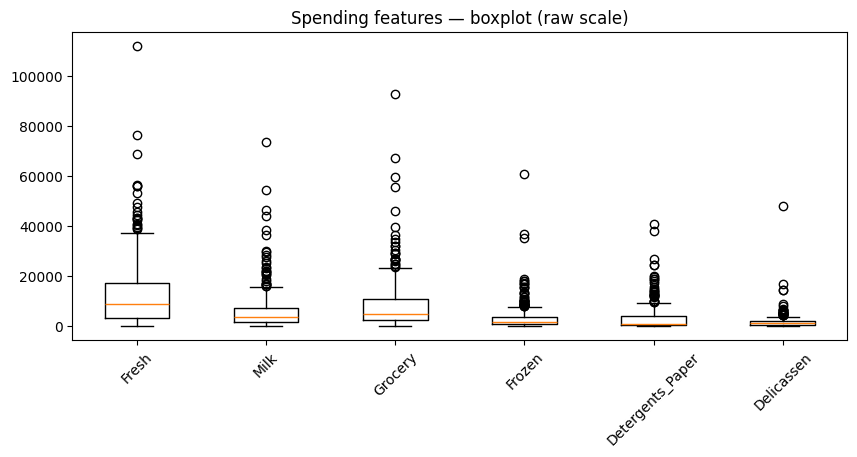

In [ ]:
plt.figure(figsize=(10,4))
plt.boxplot(X, tick_labels=features_cols)
plt.xticks(rotation=45)
plt.title("Spending features — boxplot (raw scale)")
plt.show()

The spending variables have very different ranges and show strong right-skewness with many extreme values (outliers), as highlighted by the boxplots.  
For this reason, we apply a log1p transformation to compress large values and reduce skewness, making distances more meaningful.  
Then we use StandardScale to standardize all features, since the clustering algorithms are distance-based and should not be dominated by variables with larger scales.


## Preprocessing

In this section we prepare the data for clustering.

1. We **select the 6 numerical spending features**, since they represent the customer purchasing profile and are the variables on which we want to build the clusters.



In [ ]:
features = ["Fresh","Milk","Grocery","Frozen","Detergents_Paper","Delicassen"]
X = df[features].copy()


2. We apply a **logarithmic transformation** to reduce **skewness and the impact of outliers**.



In [ ]:
X_log = np.log1p(X)


3. We apply **standardization** (z-score) using `StandardScaler`, so that each feature has mean 0 and variance 1. This is crucial because distance-based clustering methods (e.g., **K-means, Agglomerative, DBSCAN**) are sensitive to feature scales.


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)


4. Finally, we run a few **sanity checks**: dataset shape and  missing values.

In [ ]:
print("Shape original X:", X.shape)
print("Shape scaled X:", X_scaled.shape)
print("\nMissing values (features):")
print(X.isna().sum())



Shape original X: (440, 6)
Shape scaled X: (440, 6)

Missing values (features):
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


## Step 3 — Dimensionality reduction for visualization (PCA)

The dataset has 6 numerical features, so clusters live in a **6-dimensional space** and cannot be directly visualized.  
To inspect the structure of the data and the clustering results, we apply **Principal Component Analysis (PCA)** and project the standardized data into **2 dimensions**.

We underline the fact tha **PCA is used only for visualization**, not to “improve” the clustering itself.  
We will still run the clustering algorithms on the full standardized feature space, and then plot the resulting labels in the 2D PCA plane.

In order to prove the reliability of PCA procedure for our dataset we check how much of the overall variance in explaned by the first two variables:


,PC,Explained variance ratio,Cumulative explained variance
0,PC1,0.440778,0.440778
1,PC2,0.271949,0.712727
2,PC3,0.106984,0.819711
3,PC4,0.101033,0.920744
4,PC5,0.048763,0.969507
5,PC6,0.030493,1.000000


Total explained variance by PC1+PC2: 0.7127266893428759


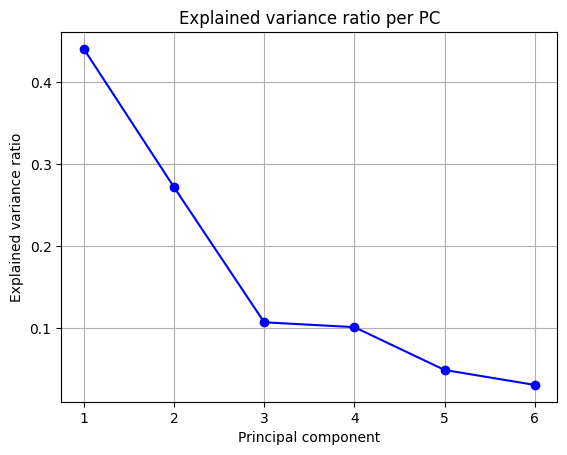

In [ ]:
pca = PCA()
pca.fit(X_scaled)
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)
pca_table = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained))],
    "Explained variance ratio": explained,
    "Cumulative explained variance": cum_explained
})
display(pca_table)

print("Total explained variance by PC1+PC2:", cum_explained[1])

# Plot explained variance per component
plt.figure()
plt.plot(range(1, len(explained)+1), explained, "bo-")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Explained variance ratio per PC")
plt.grid(True)
plt.show()




PCA shows that the first two components explain a large fraction of the total variability: **PC1 ≈ 44.1%** and **PC2 ≈ 27.2%**, for a total of **≈ 71.3%**.  
Therefore, plotting the samples in the 2 dimension PCA plane provides a meaningful low-dimensional visualization of the dataset, even though some information (≈ 28.7%) is still contained in the remaining components.


Explained variance ratio (PC1, PC2): [0.44077752 0.27194917]
Total explained variance (PC1+PC2): 0.7127266893428759


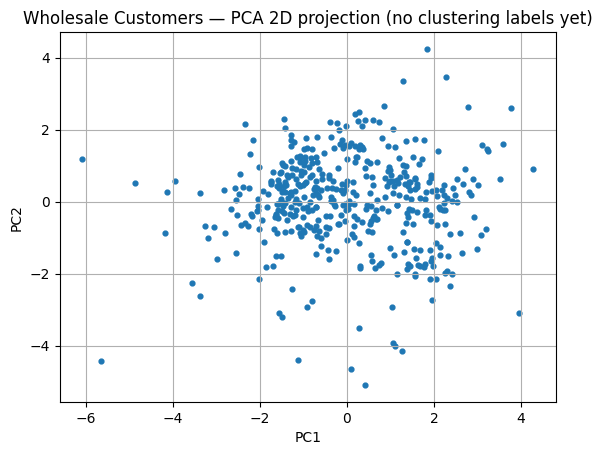

In [ ]:
# Fit PCA on the standardized data (6D -> 2D)
pca = PCA(n_components=2, random_state=0)
X_pca2 = pca.fit_transform(X_scaled)

# Print how much variance is explained by the first 2 components
print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)
print("Total explained variance (PC1+PC2):", pca.explained_variance_ratio_.sum())


plt.figure()
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], s=12)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wholesale Customers — PCA 2D projection (no clustering labels yet)")
plt.grid(True)
plt.show()


In the PCA projection the data points form a single dense cloud with no clearly separated groups. This suggests that any cluster structure in the Wholesale Customers dataset is not strongly evident (at least in the first two principal components) and that clusters may overlap. Therefore, PCA is mainly used here for visualization and outlier inspection, while clustering quality is assessed in the full 6D standardized space using internal metrics.


## Step 4 — K-means clustering and choice of the number of clusters (k)

We start with **K-means** as a baseline clustering method.
We first add the main helper functions wich will help up so plot the main descriptive results of the K-Means algorithm application.


In [ ]:
def plot_predictions(clf, axes, confidence=True):
    # Create a mesh grid
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    # Compute predictions for mesh points
    X_ = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X_).reshape(x0.shape)
    # Plot predictions
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    # Plot confidence scores for samples
    if confidence:
        y_decision = clf.decision_function(X_).reshape(x0.shape)
        plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)
    return

# Helper function to plot data with features X and label y
def plot_dataset_(X, y, axes, x1_index=0, x2_index=1, labels=[]):
    for item, style in zip(set(y), ["bs", "g+", "yo", "rv", "c<", "m<"]):
        plt.plot(X[:, x1_index][y==item], X[:, x2_index][y==item], style)
    if axes != []:
        plt.axis(axes)
    plt.grid(True, which='both')
    # Add axes labels
    if labels != []:
        plt.xlabel(labels[x1_index], fontsize=12)
        plt.ylabel(labels[x2_index], fontsize=12)
    else:
        plt.xlabel(r"$x_1$", fontsize=12)
        plt.ylabel(r"$x_2$", fontsize=12, rotation=0)
    return

# Wrapper to plot a dataset
def plot_dataset(X, y, title, x1_index=0, x2_index=1, labels=[]):
    plot_dataset_(X, y, [], x1_index=x1_index, x2_index=x2_index, labels=labels)
    plt.title(title)
    plt.show()
    return

# Wrapper to plot k-means results
def plot_kmeans_results(clf, X, y, title="", axes=[]):
    # Compute axes to use (i.e., plot axis ranges)
    if axes == []:
        for i in [0,1]:
            min_x = min(X[:,i])
            max_x = max(X[:,i])
            delta_x = (max_x-min_x)/20
            axes += [min_x-delta_x, max_x+delta_x]
    # Plot the model predictions as colored regions
    plot_predictions(clf, axes, confidence=False)
    # Plot data on top
    plot_dataset_(X, y, axes)
    # Plot centroids if available
    try:
        centroids_x = [x[0] for x in clf.cluster_centers_]
        centroids_y = [x[1] for x in clf.cluster_centers_]
        plt.plot(centroids_x, centroids_y, "k+", mew=3, ms=12)
    except:
        pass
    # Add title and show plot
    plt.title(title)
    plt.show()
    return

## Step 5 - Choosing the Appropriate Number of Clusters for K-Means

There are two **graphical ways** that allow to *estimate* the **optimal number of clusters K** for a given dataset:
1. The **elbow method**
2. The **silhouette coefficient**

In [ ]:
def get_SSE(data, clustering_algorithm, max_clusters=15):
    SSE = []
    # Calculate SSE for each number of clusters, from k=2 to k=max_clusters-1
    for k in range(2, max_clusters):
        # set the clustering algorithm
        model = clustering_algorithm(n_clusters=k, random_state=0, n_init=10)
        # train and predict from data
        model.fit_predict(data)
        # add SSE to the list of SSEs
        SSE.append(model.inertia_)
    return SSE

# Plot SSE vs the number of clusters k
def plot_SSE(data, clustering_algorithm, title="", max_clusters=15):
    SSE = get_SSE(data, clustering_algorithm, max_clusters=max_clusters)
    plt.figure()
    plt.plot(range(2, max_clusters), SSE, 'bo-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Sum of squared distances to centroid (Inertia / SSE)')
    plt.title(title)
    plt.grid(True)
    plt.show()
    return

def get_silhouette_score(data, clustering_algorithm, max_clusters=15):
    silhouette_coefficients = []
    # Calculate silhouette score for each number of clusters, from k=2 to k=max_clusters-1
    for k in range(2, max_clusters):
        # set the clustering algorithm
        model = clustering_algorithm(n_clusters=k, random_state=0, n_init=10)
        # train and predict from data
        model.fit_predict(data)
        # calculate silhouette score for the current number of clusters
        score = silhouette_score(data, model.labels_)
        # add silhouette score to the list
        silhouette_coefficients.append(score)
    return silhouette_coefficients

# Plot silhouette score vs the number of clusters k
def plot_silhouette_score(data, clustering_algorithm, title="", max_clusters=15):
    sil_scores = get_silhouette_score(data, clustering_algorithm, max_clusters=max_clusters)
    plt.figure()
    plt.plot(range(2, max_clusters), sil_scores, 'bo-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette coefficient')
    plt.title(title)
    plt.grid(True)
    plt.show()
    return

In [ ]:
Ks = range(2, 11)
scores = []

for k in Ks:
    model = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = model.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

best_k = Ks[np.argmax(scores)]


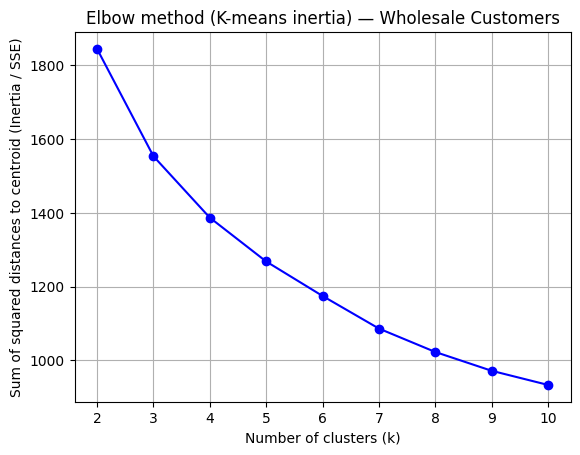

In [ ]:
plot_SSE(X_scaled, KMeans, title="Elbow method (K-means inertia) — Wholesale Customers", max_clusters=11)

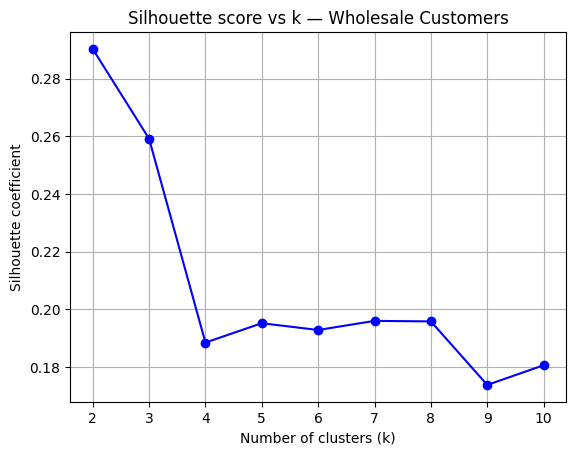

In [ ]:
plot_silhouette_score(X_scaled, KMeans, title="Silhouette score vs k — Wholesale Customers", max_clusters=11)

The **Elbow plot** decreases as `k` increases, but the improvement becomes much smaller after the first few values. In our curve the largest gains are between **k = 2 and k = 4**, and then the decrease becomes more gradual, suggesting an elbow around **k ≈ 3–4**.

The **Silhouette plot** is maximized at **k = 2**  and is slightly lower at **k = 3**; for `k ≥ 4` the silhouette drops and remains around ~0.19, indicating less well-separated clusters.

Overall, a reasonable choice is **k = 2** if we want the strongest separation, or **k = 3 (or 4)** as a compromise to obtain a more detailed segmentation while still keeping inertia improvements meaningful.

In this work we select **k = 2** for K-means, since it achieves the highest silhouette score on X_scaled and therefore provides the clearest separation between groups.




Cluster sizes:
0    252
1    188
Name: count, dtype: int64


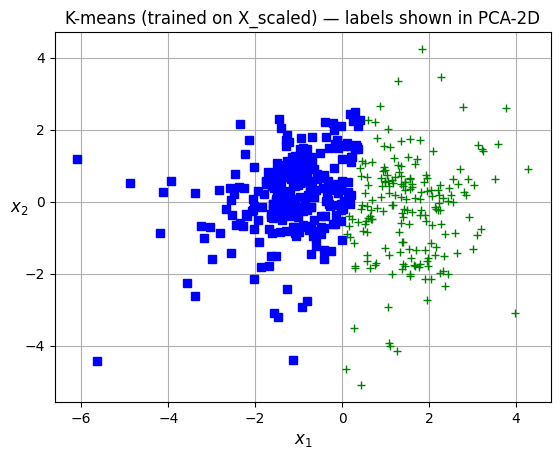


Centroid of each cluster (in 6D scaled space):
 [[ 0.22094842 -0.60363163 -0.64156249  0.25747254 -0.66031356 -0.14977564]
 [-0.2961649   0.80912324  0.85996674 -0.34512277  0.88510115  0.20076309]]
SSE (inertia):  1844.0640687542127
N. iterations:  14


In [ ]:
clustering = KMeans(n_clusters=2, random_state=0, n_init=10)
# train and predict from data
labels_kmeans = clustering.fit_predict(X_scaled)

# cluster sizes
print("\nCluster sizes:")
print(pd.Series(labels_kmeans).value_counts().sort_index())

# visualize labels in PCA-2D (scatter only)
plot_dataset(X_pca2, labels_kmeans,title="K-means (trained on X_scaled) — labels shown in PCA-2D")

# print centroids and other information
print("\nCentroid of each cluster (in 6D scaled space):\n", clustering.cluster_centers_)
print("SSE : ", clustering.inertia_)
print("N. iterations: ", clustering.n_iter_)


## Agglomerative (Hierarchical) Clustering

In this section we apply **hierarchical clustering** using the **Agglomerative** approach.  
Unlike K-means, hierarchical clustering does not rely on centroids: it starts with each sample as its own cluster and then **iteratively merges** the two closest clusters until only one cluster remains (or until we stop at a chosen number of clusters).


We first select the number of clusters by inspecting the silhouette-vs-k curve; in our case the highest silhouette is obtained at **k = 2**, suggesting that a two-group partition gives the clearest separation.  



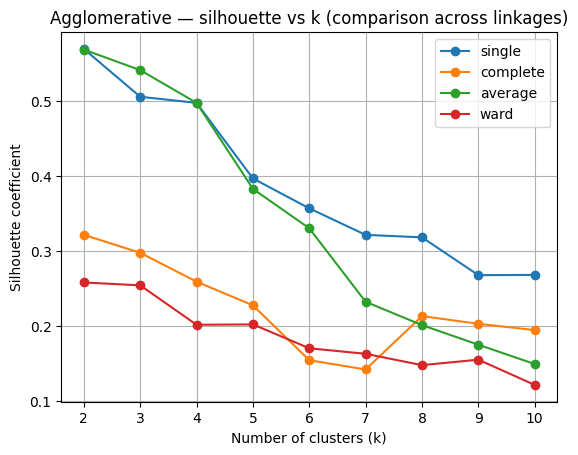

In [ ]:
Ks = range(2, 11)
linkages = ["single", "complete", "average", "ward"]
plt.figure()
for link in linkages:
    scores = []
    for k in Ks:
        labels_agg = AgglomerativeClustering(n_clusters=k, linkage=link).fit_predict(X_scaled)
        scores.append(silhouette_score(X_scaled, labels_agg))
    plt.plot(list(Ks), scores, "o-", label=link)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette coefficient")
plt.title("Agglomerative — silhouette vs k (comparison across linkages)")
plt.grid(True)
plt.legend()
plt.show()


### 2) Agglomerative Clustering with different linkage criteria

Then, keeping **k fixed**, we compare different linkage criteria (single, complete, average, ward).
Because our original feature space is 6-dimensional, we fit the clustering algorithm on the **full preprocessed data** (X_scaled), and then we visualize the resulting labels on the **PCA projection** (X_pca2).

Agglomerative clustering requires a **linkage criterion**, which defines the distance between clusters:
- **single**: distance between the closest points
- **complete**: distance between the farthest points
- **average**: average distance between points
- **ward**: minimizes within-cluster variance (often effective on standardized data).



Linkage:   single | silhouette: 0.570
Cluster sizes: {0: 439, 1: 1}


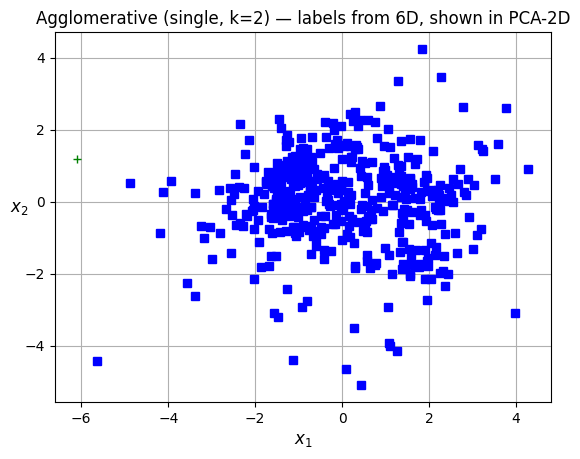


Linkage: complete | silhouette: 0.322
Cluster sizes: {0: 38, 1: 402}


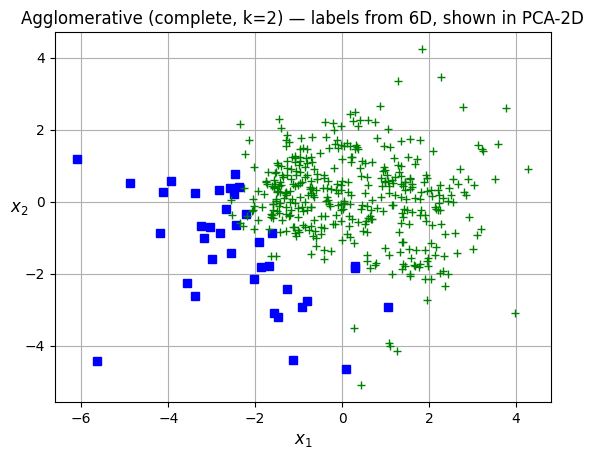


Linkage:  average | silhouette: 0.569
Cluster sizes: {0: 2, 1: 438}


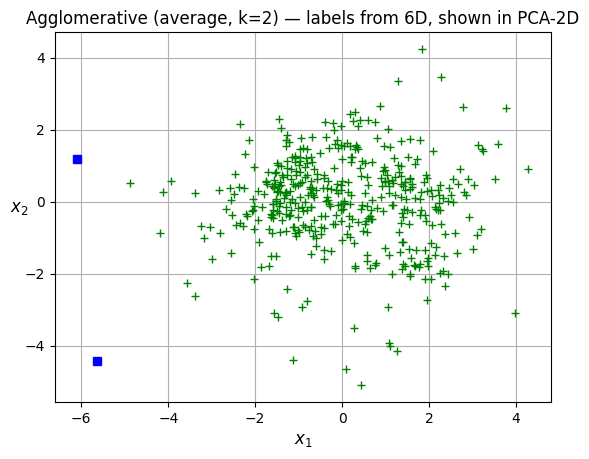


Linkage:     ward | silhouette: 0.258
Cluster sizes: {0: 178, 1: 262}


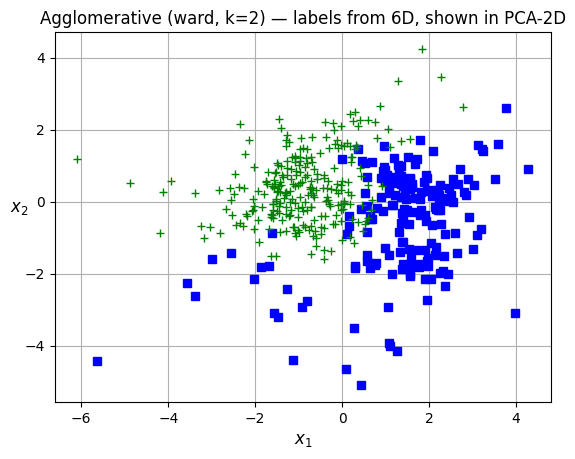

In [ ]:
k = 2
linkages = ["single", "complete", "average", "ward"]

for link in linkages:
    clustering = AgglomerativeClustering(n_clusters=k, linkage=link)
    labels = clustering.fit_predict(X_scaled)  # fit in 6D

    sil = silhouette_score(X_scaled, labels)
    counts = pd.Series(labels).value_counts().sort_index()

    print(f"\nLinkage: {link:>8} | silhouette: {sil:.3f}")
    print("Cluster sizes:", counts.to_dict())

    # visualize in PCA-2D
    plot_dataset(X_pca2, labels,
                 title=f"Agglomerative ({link}, k={k}) — labels from 6D, shown in PCA-2D")



### Interpretation of linkage comparison

With **single** and **average** linkage, the result is dominated by **one very large cluster** and a few very small clusters. This is why clusters can grow by progressively linking points through “bridges”, producing unbalanced partitions that are not very informative.

With **complete** linkage the partition is slightly more structured, but it still tends to isolate a small group of points rather than producing well-balanced clusters.

**ward** linkage produces the most interpretable result: clusters appear more compact and better separated in the PCA-2D projection, which is consistent with Ward’s criterion (it merges clusters by minimizing the increase of within-cluster variance). For this reason, Ward is the preferred linkage for this dataset among the tested options.


In [ ]:
k_agg = 2
linkages = ["single", "complete", "average", "ward"]

rows = []
for link in linkages:
    model = AgglomerativeClustering(n_clusters=k_agg, linkage=link)
    labels = model.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    counts = pd.Series(labels).value_counts().sort_index()

    rows.append({
        "linkage": link,
        "silhouette": sil,
        "cluster_sizes": dict(counts)
    })

agg_summary = pd.DataFrame(rows)
agg_summary


,linkage,silhouette,cluster_sizes
0,single,0.569978,"{0: 439, 1: 1}"
1,complete,0.322005,"{0: 38, 1: 402}"
2,average,0.569055,"{0: 2, 1: 438}"
3,ward,0.258495,"{0: 178, 1: 262}"


### Dendrogram (hierarchical tree)
We  plot a **dendrogram**, which is a tree representation of the merge process.  
The dendrogram helps us visualize the hierarchical structure of the data and how clusters are progressively merged at increasing distances.  
Since the dataset contains many samples, we show only the **top levels** of the tree, which is sufficient to observe the main merging structure.


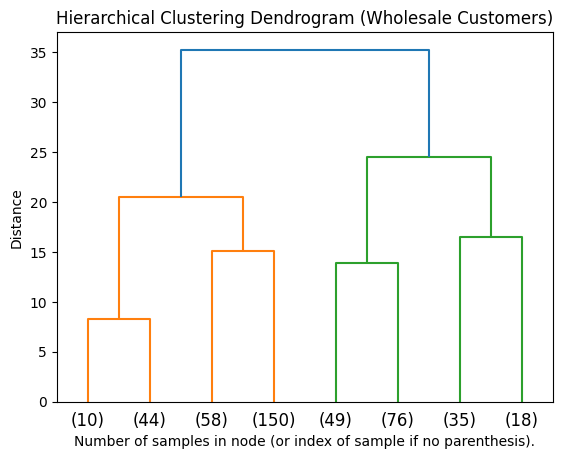

In [ ]:
plt.figure()
shc.dendrogram(shc.linkage(X_scaled, method='ward'),truncate_mode='level',p=2)
plt.title("Hierarchical Clustering Dendrogram (Wholesale Customers)")
plt.xlabel("Number of samples in node (or index of sample if no parenthesis).")
plt.ylabel("Distance")
plt.show()

## DBSCAN clustering

In this section we apply **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise).  
Unlike K-means and Agglomerative clustering, DBSCAN does **not** require specifying the number of clusters in advance. Instead, it groups together points that lie in high-density regions and labels isolated points as **noise/outliers** (label `-1`).

DBSCAN is particularly useful when clusters have **arbitrary shapes** and when we want an explicit notion of **outliers**.  
However, DBSCAN can be sensitive to the choice of its hyperparameters (**eps** and **min_samples**) and may struggle in higher-dimensional spaces.


### choosing eps with the k-distance plot

DBSCAN requires two parameters:
- `min_samples` (also called **MinPts**): the minimum number of points required to form a dense region
- `eps`: the neighborhood radius used to define density.

To select a reasonable value of **eps**, we use the **k-distance plot**:
1. Fix **k = min_samples**.
2. For each sample, compute the distance to its **k-th nearest neighbor**.
3. Sort these distances and plot them.

In dense regions (potential clusters) the k-th neighbor distance is small and the curve grows slowly.
When the curve shows a **sharp increase (knee/elbow)**, it indicates the transition from dense regions to sparse points (likely **noise/outliers**).  
We choose `eps` around this knee.



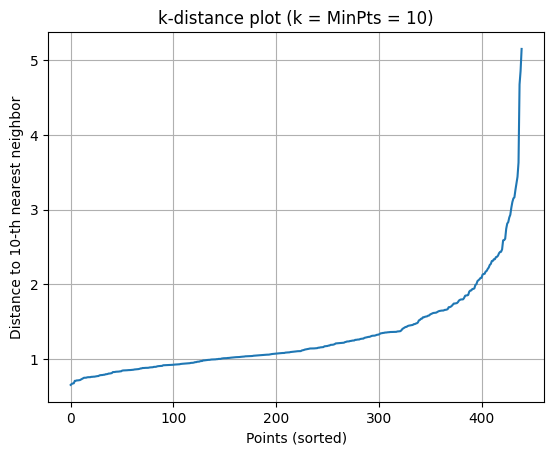

In [ ]:
#choose MinPts
min_samples = 10

#k-distance plot:
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure()
plt.plot(k_dist)
plt.title(f"k-distance plot (k = MinPts = {min_samples})")
plt.xlabel("Points (sorted)")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.grid(True)
plt.show()


We select **MinPts = 10** and compute the **k-distance plot**, i.e., the sorted distance of each point to its 10-th nearest neighbor.  
**eps** is chosen at the “elbow” of this curve: points in dense regions have small k-distances (flat part), while noise/outliers cause a sharp increase (steep tail).  
We therefore set **eps ≈ 1.5**, just before the rapid rise, and run DBSCAN with these parameters.


### DBSCAN: fitting the model and interpreting the output

After selecting **eps** (from the k-distance plot) and fixing **min_samples**, we fit DBSCAN on *our dataset.  
DBSCAN assigns:
- a cluster label `0, 1, 2, ...` to points belonging to dense regions,
- the label `-1` to **noise points** (outliers).

we recall that the original feature space is 6D, we visualize the clustering by plotting the labels on a **PCA-2D projection** ).


In [ ]:
min_samples=10
eps = 1.5
db = DBSCAN(eps=eps, min_samples=min_samples)
labels_dbscan = db.fit_predict(X_scaled)


DBSCAN parameters -> eps: 1.5 min_samples: 10
Number of clusters (excluding noise): 2
Number of noise points: 0 (0.0%)


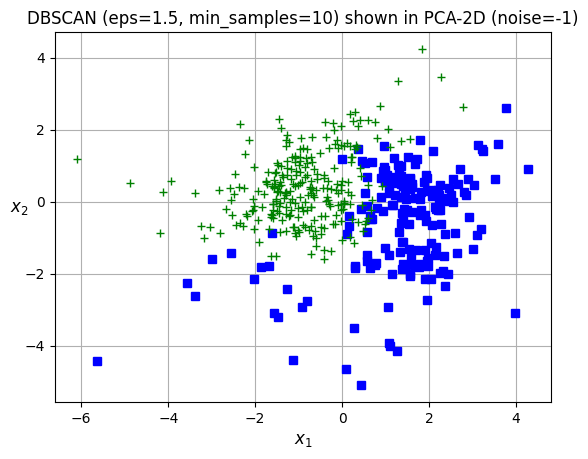


Cluster sizes (excluding noise):
0    178
1    262
Name: count, dtype: int64


In [ ]:

n_noise = int(np.sum(labels == -1))
n_clusters = int(len(set(labels)) - (1 if -1 in labels else 0))

print("DBSCAN parameters -> eps:", eps, "min_samples:", min_samples)
print("Number of clusters (excluding noise):", n_clusters)
print("Number of noise points:", n_noise, f"({n_noise/len(labels):.1%})")

#Save labels into the dataframe
df["cluster_dbscan"] = labels

# Plot labels in PCA-2D
plot_dataset(X_pca2, labels, title=f"DBSCAN (eps={eps}, min_samples={min_samples}) shown in PCA-2D (noise=-1)")
print("\nCluster sizes (excluding noise):")
print(pd.Series(labels[labels != -1]).value_counts().sort_index())


With **eps**= 1.5` and **MinPts = 10**, DBSCAN identifies **one main dense cluster** (392 customers) and labels **48 customers (10.9%) as noise/outliers**.  
This suggests that, in the 6D standardized feature space, most customers form a single coherent density region, while a smaller subset has isolated spending profiles that do not belong to any dense neighborhood.


## 4. Evaluation of clustering performances

There are two categories of metrcs for evaluating the performances of a clustering model: external metrics and internal metrics.

### Internal evaluation metrics

Since we do not have ground-truth labels, we evaluate clustering quality using **internal indices**:


- **Silhouette coefficient**: combines cohesion and separation
- **Correlation-based validity**: correlation between a **proximity (distance) matrix** and an **ideal similarity matrix**
  (1 if two points are in the same cluster, 0 otherwise). A high magnitude correlation indicates that
  points assigned to the same cluster are close to each other.

All metrics are computed on the dtaset X_scaled.  
For DBSCAN, noise points (label = -1) are excluded from the evaluation.



In [ ]:
def _drop_noise(X, labels):
    labels = np.asarray(labels)
    mask = labels != -1
    return X[mask], labels[mask]

def compute_sse(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)
    sse = 0.0
    for c in np.unique(labels):
        Xc = X[labels == c]
        if len(Xc) == 0:
            continue
        centroid = Xc.mean(axis=0)
        sse += np.sum((Xc - centroid) ** 2)
    return float(sse)

def compute_silhouette(X, labels):
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2:
        return np.nan
    return float(silhouette_score(X, labels))



In [ ]:
# helper function that sorts some data given the cluster labels
def sort_data(data, cluster_labels):
    sorting_indexes = np.argsort(cluster_labels)
    sorted_data = data[sorting_indexes]
    return sorted_data, sorting_indexes

def get_clustering_matrix(data, cluster_labels):
    sorted_data, _ = sort_data(data, cluster_labels)
    distance_matrix = pairwise_distances(sorted_data)
    return distance_matrix

# plot a distance matrix
def plot_clustering_matrix(data, cluster_labels, title=""):
    distance_matrix = get_clustering_matrix(data, cluster_labels)
    fig, ax = plt.subplots()
    im = ax.imshow(distance_matrix, cmap='jet_r')
    fig.colorbar(im)
    plt.title(title)
    plt.show()
    return



### K-Means ###
Average Silhouette Score (no-noise): 0.290


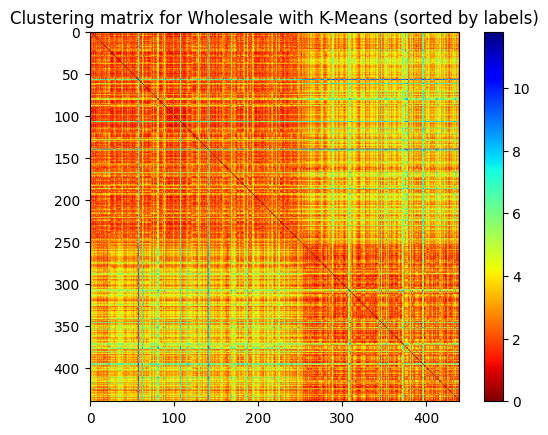


### DBSCAN ###
Average Silhouette Score: not defined (need >= 2 clusters among non-noise points).


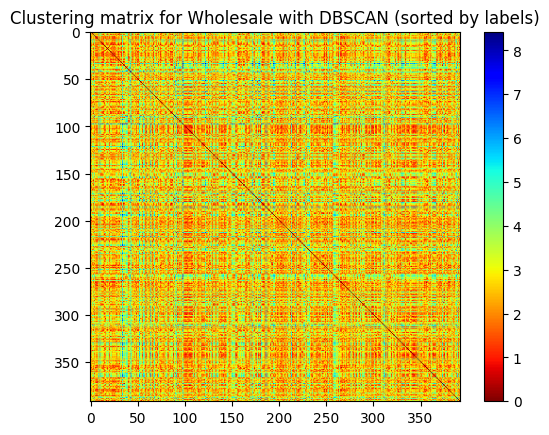


### Hierarchical ###
Average Silhouette Score (no-noise): 0.258


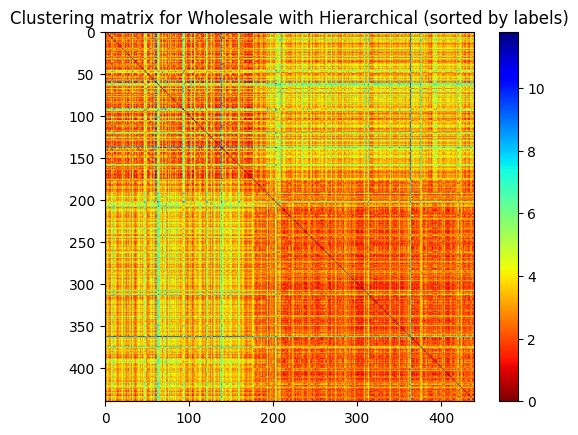

In [ ]:
#set hyperparameters
k = 2
eps = 1.5
min_samples = 10
linkage = "ward"

models = [
    (KMeans(n_clusters=k, random_state=0, n_init=10), "K-Means"),
    (DBSCAN(eps=eps, min_samples=min_samples), "DBSCAN"),
    (AgglomerativeClustering(n_clusters=k, linkage=linkage), "Hierarchical")
]

for model, title in models:
    print("\n###", title, "###")

    # train and predict from data (6D)
    labels = model.fit_predict(X_scaled)

    # silhouette score (exclude noise if present)
    mask = labels != -1
    n_clusters = len(set(labels[mask]))

    if np.sum(mask) > 1 and n_clusters >= 2:
        s_score = silhouette_score(X_scaled[mask], labels[mask])
        print("Average Silhouette Score (no-noise):", "{:.3f}".format(s_score))
    else:
        print("Average Silhouette Score: not defined (need >= 2 clusters among non-noise points).")


    plot_clustering_matrix(X_scaled[mask], labels[mask],
                           title=f"Clustering matrix for Wholesale with {title} (sorted by labels)")


We evaluate the clustering results using **internal validation** , since the dataset has no ground-truth labels for customer segments.

We report the **average silhouette coefficient** (higher is better) and visualize a **distance-based clustering matrix** which represent pairwise distances between samples, sorted by the predicted labels. In the matrix, compact clusters appear as clearer blocks along the diagonal.

- **K-Means** achieves an average silhouette of about **0.29**, indicating a modest separation between clusters. The clustering matrix shows some block structure, but it is not extremely sharp, suggesting partially overlapping groups in the 6D feature space.
- **Hierarchical clustering (ward)** obtains a slightly lower silhouette (about **0.26**), with a similar matrix structure, meaning the partition is comparable but not stronger than K-Means.
- For **DBSCAN**, the silhouette score is **not defined** because DBSCAN finds **only one cluster among non-noise points** (plus noise). In this configuration DBSCAN mainly behaves as a **core vs outliers** detector rather than producing multiple customer segments.



### Internal evaluation metrics

To evaluate how similar our clustering assignments are to the available categorical variables (Channel` and `Region), we compute two **external validity** measures:

- **ARI (Adjusted Rand Index)**: compares two partitions (true labels vs cluster labels) by counting how consistently pairs of samples are grouped together or separated.  
  It is *adjusted for chance*, so random clusterings tend to score close to **0**.  
  **Interpretation**: **1** = perfect agreement, **0** ≈ random agreement, **< 0** = worse than random.

- **NMI (Normalized Mutual Information)**: measures how much information is shared between the two labelings (how predictive one partition is of the other).  
  It is normalized to lie in **[0, 1]**.  
  **Interpretation**: **1** = perfect correspondence, **0** = no relationship.

We disclaim that Channel and Region are not guaranteed to be the “true” clusters, but they can be used as **reference labels** to check whether the discovered clusters align with these known categories.


In [ ]:
y_channel = df["Channel"].astype(int).to_numpy()
y_region  = df["Region"].astype(int).to_numpy()

def external_validity(y_true, y_pred, drop_noise=False):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if drop_noise:
        mask = (y_pred != -1)
        y_true = y_true[mask]
        y_pred = y_pred[mask]

    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred, average_method="arithmetic")
    return ari, nmi, len(y_true)

results = []

models = [("KMeans", labels_kmeans, False),("Agglomerative", labels_agg, False),("DBSCAN", labels_dbscan, True) ]

for name, y_pred, drop_noise in models:
    ari_c, nmi_c, n_used_c = external_validity(y_channel, y_pred, drop_noise=drop_noise)
    ari_r, nmi_r, n_used_r = external_validity(y_region,  y_pred, drop_noise=drop_noise)

    results.append({
        "model": name,
        "drop_noise_for_DBSCAN": drop_noise,
        "ARI_vs_Channel": ari_c,
        "NMI_vs_Channel": nmi_c,
        "ARI_vs_Region": ari_r,
        "NMI_vs_Region": nmi_r,
        "n_samples_used": n_used_c
    })

pd.DataFrame(results)


,model,drop_noise_for_DBSCAN,ARI_vs_Channel,NMI_vs_Channel,ARI_vs_Region,NMI_vs_Region,n_samples_used
0,KMeans,False,0.513543,0.445425,-0.007655,0.001923,440
1,Agglomerative,False,0.157021,0.265045,-0.010274,0.013877,440
2,DBSCAN,True,0.000000,0.000000,0.000000,0.000000,392




- **K-Means** shows a clear agreement with **Channel** (ARI ≈ 0.51, NMI ≈ 0.45), meaning that the spending-based clusters are fairly consistent with the Horeca vs Retail split.  
  In contrast, the agreement with **Region** is ~0, suggesting that the clusters are not driven by geographic region.

- **Agglomerative clustering** has a weaker agreement with **Channel** (ARI ≈ 0.16, NMI ≈ 0.27) and again ~0 agreement with **Region**.

- **DBSCAN** gives ARI/NMI ≈ 0 because with the chosen parameters it effectively produces a single dense cluster (plus noise). In this configuration DBSCAN behaves mainly as an outlier detector rather than a multi-cluster segmentation.


We do **not** include more advanced methods such as **Spectral Clustering** or **Fuzzy Clustering** in the project:
- **Spectral clustering** is particularly useful when clusters have **non-linear shapes** (e.g., moons/circles) or when a **graph-based similarity** representation is clearly justified. In our case (440 customers described by 6 numerical spending variables), we did not observe clear evidence that a graph construction step would improve interpretability, while it would increase modelling complexity and add additional hyperparameters (similarity graph, kernel/scale, etc.).
- **Fuzzy clustering** (e.g., fuzzy c-means) produces **soft memberships** (a customer can partially belong to multiple clusters). While potentially interesting, it complicates the interpretation and the evaluation used in the lab, which is mostly based on crisp partitions (hard cluster assignments).

Finally, the dataset has a relatively small number of features (6 numerical variables), which makes standard **Euclidean distance-based** clustering more reasonable than in very high-dimensional settings; however, preprocessing (log-transform + standardization) remains essential due to skewness and different feature scales.

